Templates saved:
../data/xi_bao_template.txt
../data/xi_nowiggle_template.txt


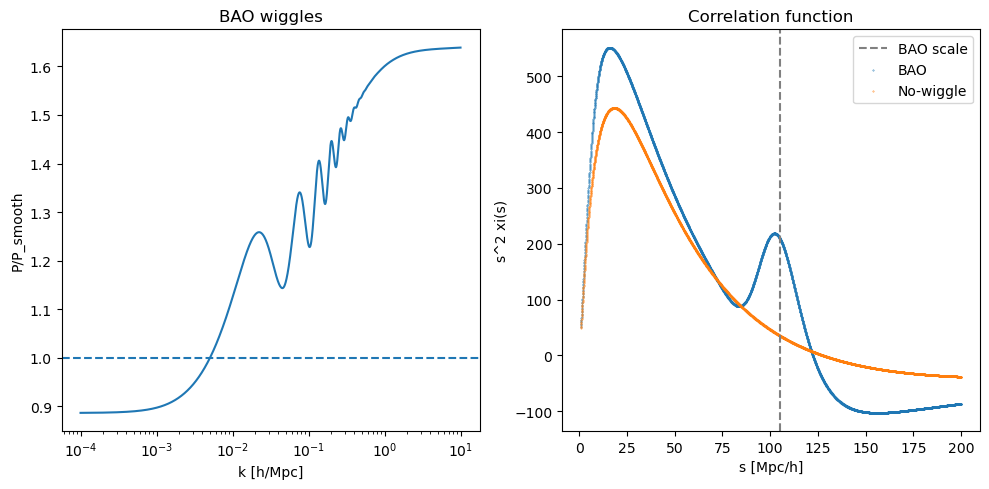


=== BAO FIT RESULTS ===
alpha  = 0.9522
B      = 0.3539
Sigma  = 6.0000
A0, A1, A2 = 0.0010, -0.1056, -0.0021



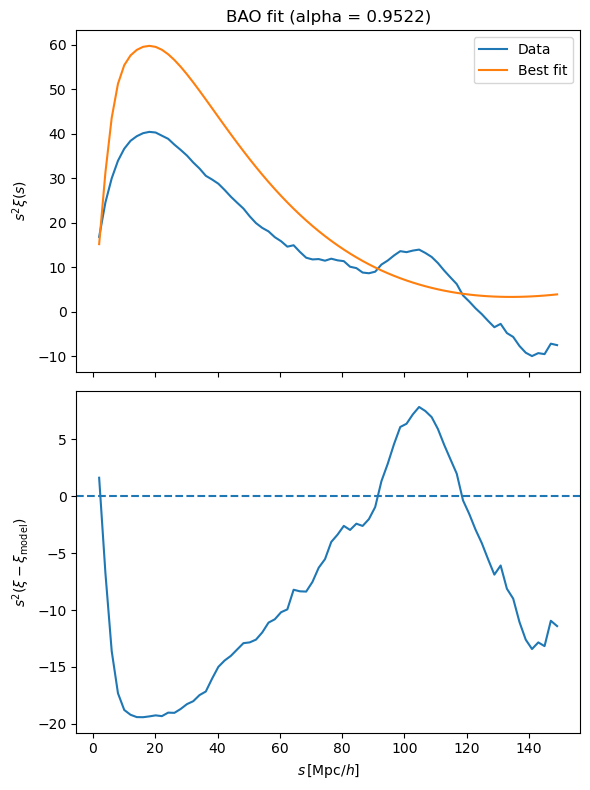

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 5.777298347060621e-06
        x: [ 9.522e-01  3.539e-01  6.000e+00  9.710e-04 -1.056e-01
            -2.100e-03]
      nit: 22
      jac: [ 8.220e-06 -4.805e-07  0.000e+00 -5.777e-04 -1.315e-05
            -1.506e-07]
     nfev: 224
     njev: 32
 hess_inv: <6x6 LbfgsInvHessProduct with dtype=float64>

In [ ]:
import numpy as np
import camb
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt

def pk_nowiggle_eh(k, H0, ombh2, omch2, ns):
    """
    Eisenstein & Hu 1998 no-wiggle power spectrum
    k: 1D array in h/Mpc
    H0: Hubble parameter [km/s/Mpc]
    ombh2, omch2: baryon and CDM densities
    ns: spectral index
    Returns: P_nw(k) in arbitrary units (can be normalized later)
    """

    h = H0 / 100.0
    Omega_b = ombh2 / h**2
    Omega_c = omch2 / h**2
    Omega_m = Omega_b + Omega_c

    f_b = Omega_b / Omega_m
    f_c = Omega_c / Omega_m

    # EH shape parameter
    theta = 2.725/2.7  # CMB temperature factor
    s = 44.5 * np.log(9.83/Omega_m*h) / np.sqrt(1 + 10*(Omega_b*h**2)**0.75)  # sound horizon, Mpc NOT USED

    # Scaled wavenumber (EQ. 28)
    q = k * theta**2 / (Omega_m*h**2) 

    # Alpha_c and beta_c (CDM transfer function) (EQs. 11-12)
    alpha_c = (1 - 0.328*np.log(431*Omega_m*h**2)*Omega_b/Omega_m + 
               0.38*np.log(22.3*Omega_m*h**2)*(Omega_b/Omega_m)**2)
    beta_c = 1 / (1 + 0.2*(Omega_c*h**2)**0.5)

    # CDM no-wiggle transfer function (EQ. 29)
    L0 = np.log(2*np.e + 1.8*beta_c*q)
    C0 = 14.2 + 731/(1 + 62.5*q)
    Tc_nw = L0 / (L0 + C0*q**2)

    # Baryon no-wiggle transfer function
    Tb_nw = Tc_nw  # for no-wiggle, baryons follow CDM approximately

    # Combine weighted by fractions
    T_nw = f_b * Tb_nw + f_c * Tc_nw

    # Power spectrum (arbitrary normalization)
    P_nw = k**ns * T_nw**2

    return P_nw

# ============================================================
# 1. Main function
# ============================================================

def generate_templates(
    z=0.0,
    H0=67.3,
    ombh2=0.022,
    omch2=0.119,
    ns=0.96,
    kmax=10.0,
    nk=8000,
    smin=1.0,
    smax=200.0,
    n_s=5000,
    smooth_factor_ratio=0.0005,
    Sigma_nl=5.0,              # BAO damping scale [Mpc/h]
    save_path="../data/",
    plot=True
):
    """
    Generate real-space BAO templates ξ(s) and ξ_nowiggle(s)
    """

    # -------------------------------------------------
    # 1. CAMB linear P(k)
    # -------------------------------------------------
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2)
    pars.InitPower.set_params(ns=ns)
    pars.set_matter_power(redshifts=[z], kmax=kmax)

    results = camb.get_results(pars)
    k, _, pk = results.get_matter_power_spectrum(
        minkh=1e-4,
        maxkh=kmax,
        npoints=nk
    )
    pk = pk[0]*15.

    # -------------------------------------------------
    # 2. Smooth (no-wiggle) P(k)
    # -------------------------------------------------
    # logk = np.log(k)
    # logpk = np.log(pk)

    # s_spline = smooth_factor_ratio * len(k)
    # spline = UnivariateSpline(logk, logpk, s=s_spline, k=3)

    # pk_smooth = np.exp(spline(logk))

    # -------------------------------------------------
    # 2. No-wiggle P(k) from EH
    # -------------------------------------------------
    pk_smooth = pk_nowiggle_eh(k, H0, ombh2, omch2, ns)

    # Match EH P_nw amplitude to CAMB at large scales
    k_match = (k > .00001) & (k < .05)  # adjust if needed
    norm_factor = np.mean(pk[k_match] / pk_smooth[k_match])
    pk_smooth *= norm_factor

    # -------------------------------------------------
    # 3. BAO damping
    # -------------------------------------------------
    damping = np.exp(-k**2 * Sigma_nl**2 / 2)

    pk_bao = pk_smooth + (pk - pk_smooth) * damping
    pk_nw  = pk_smooth

    # -------------------------------------------------
    # 4. Fourier transform → ξ(s)
    # -------------------------------------------------
    s_arr = np.linspace(smin, smax, n_s)

    xi_bao = []
    xi_nw  = []

    # mild high-k cutoff to stabilize integral
    k_cut = 5.0
    window = np.exp(-(k / k_cut)**2)
    #window = 1

    for r in s_arr:
        sinc = np.sin(k * r) / (k * r)

        integrand_bao = k**2 * pk_bao * window * sinc
        integrand_nw  = k**2 * pk_nw  * window * sinc

        xi_bao.append(np.trapezoid(integrand_bao, k) / (2 * np.pi**2))
        xi_nw.append(np.trapezoid(integrand_nw,  k) / (2 * np.pi**2))

    xi_bao = np.array(xi_bao)
    xi_nw  = np.array(xi_nw)

    # -------------------------------------------------
    # 5. Save
    # -------------------------------------------------
    np.savetxt(save_path + "xi_bao_template.txt", np.c_[s_arr, xi_bao])
    np.savetxt(save_path + "xi_nowiggle_template.txt", np.c_[s_arr, xi_nw])

    print("Templates saved:")
    print(save_path + "xi_bao_template.txt")
    print(save_path + "xi_nowiggle_template.txt")

    # -------------------------------------------------
    # 6. Diagnostics
    # -------------------------------------------------
    if plot:
        plt.figure(figsize=(10,5))

        plt.subplot(1,2,1)
        plt.semilogx(k, pk / pk_smooth)
        plt.axhline(1, linestyle='--')
        plt.xlabel("k [h/Mpc]")
        plt.ylabel("P/P_smooth")
        plt.title("BAO wiggles")

        plt.subplot(1,2,2)
        plt.axvline(105, linestyle='--', color='gray', label="BAO scale")
        plt.scatter(s_arr, xi_bao * s_arr**2, label="BAO", s=.1)
        plt.scatter(s_arr, xi_nw  * s_arr**2, label="No-wiggle", s=.1)
        plt.xlabel("s [Mpc/h]")
        plt.ylabel("s^2 xi(s)")
        plt.legend()
        plt.title("Correlation function")

        plt.tight_layout()
        plt.show()

    return s_arr, xi_bao, xi_nw




generate_templates(
                    z=0.0,          # Multidark snapshot
                    Sigma_nl=5.0,   
                    plot=True
                )

import numpy as np
from scipy.interpolate import interp1d
from scipy.optimize import minimize
import matplotlib.pyplot as plt


# ============================================================
# 1. Load monopole (your pipeline output)
# ============================================================

def load_monopole(filename):
    data = np.load(filename)
    return data['s'], data['xi0']


# ============================================================
# 2. Load BAO templates (precomputed)
# ============================================================

def load_templates(path_bao, path_nw):
    s_w, xi_w = np.loadtxt(path_bao, unpack=True)
    s_nw, xi_nw = np.loadtxt(path_nw, unpack=True)
    return s_w, xi_w, xi_nw


# ============================================================
# 3. BAO model
# ============================================================

# def xi_model(s, params, s_temp, xi_w, xi_nw):
#     alpha, B, Sigma, A0, A1, A2 = params

#     interp_w = interp1d(s_temp, xi_w, kind='linear', fill_value="extrapolate")
#     interp_nw = interp1d(s_temp, xi_nw, kind='linear', fill_value="extrapolate")

#     s_scaled = alpha * s
#     xi_w_scaled  = interp_w(s_scaled)
#     xi_nw_scaled = interp_nw(s_scaled)

#     bao_term = xi_w_scaled - xi_nw_scaled
#     #damping  = np.exp(-s_scaled**2 / (2 * Sigma**2))  # s unscaled
#     xi_mod = B**2 * (xi_nw_scaled + bao_term) + A0 + A1/s + A2/s**2

#     return xi_mod
def xi_model(s, params, s_temp, xi_w, xi_nw):
    alpha, B, Sigma, A0, A1, A2 = params

    interp_w  = interp1d(s_temp, xi_w,  kind='linear', fill_value="extrapolate")
    interp_nw = interp1d(s_temp, xi_nw, kind='linear', fill_value="extrapolate")

    s_scaled = alpha * s

    xi_w_scaled  = interp_w(s_scaled)
    xi_nw_scaled = interp_nw(s_scaled)

    # BAO component only
    xi_bao = xi_w_scaled - xi_nw_scaled

    # nonlinear damping (Ross-consistent form)
    damping = np.exp(-(s_scaled**2) / (2 * Sigma**2))
    xi_bao_damped = xi_bao * damping

    # full model
    xi_model = B**2 * (xi_nw_scaled + xi_bao_damped) + A0 + A1/s + A2/s**2

    return xi_model

# ============================================================
# 4. Chi^2 (no covariance yet)
# ============================================================

def chi2(params, s, xi, s_temp, xi_w, xi_nw):
    model = xi_model(s, params, s_temp, xi_w, xi_nw)
    chi2 = np.sum((xi - model)**2)
    return chi2


# ============================================================
# 5. Fit function
# ============================================================

def fit_bao(s, xi, s_temp, xi_w, xi_nw, fit_range=(70,150)):

    mask = (s >= fit_range[0]) & (s <= fit_range[1])
    s_fit  = s[mask]
    xi_fit = xi[mask]

    p0 = [1.0, 1.0, 6.0, 0.0, 0.0, 0.0]  # alpha, B, Sigma, A0, A1, A2
    bounds = [
        (0.8, 1.2),   # alpha
        (0, None),    # B
        (0, 20),      # Sigma
        (None, None), # A0
        (None, None), # A1
        (None, None)  # A2
    ]

    result = minimize(
        chi2,
        p0,
        args=(s_fit, xi_fit, s_temp, xi_w, xi_nw),
        method='L-BFGS-B',
        bounds=bounds
    )

    return result


# ============================================================
# 6. Plot results
# ============================================================

def plot_fit(s, xi, result, s_temp, xi_w, xi_nw, title=None):

    xi_best = xi_model(s, result.x, s_temp, xi_w, xi_nw)
    residuals = xi - xi_best

    fig, ax = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

    # Top: fit
    ax[0].plot(s, xi * s**2, label='Data')
    ax[0].plot(s, xi_best * s**2, label='Best fit')
    ax[0].set_ylabel(r'$s^2 \xi(s)$')
    ax[0].legend()

    if title is not None:
        ax[0].set_title(title)

    # Bottom: residuals
    ax[1].plot(s, residuals * s**2)
    ax[1].axhline(0, linestyle='--')
    ax[1].set_xlabel(r'$s \, [\mathrm{Mpc}/h]$')
    ax[1].set_ylabel(r'$s^2 (\xi - \xi_{\mathrm{model}})$')

    plt.tight_layout()
    plt.show()


# ============================================================
# 7. High-level wrapper (what you actually call)
# ============================================================

def run_bao_fit(
    monopole_file,
    template_bao,
    template_nw,
    fit_range=(70,150)
):

    # Load data
    s, xi = load_monopole(monopole_file)

    # Load templates
    s_temp, xi_w, xi_nw = load_templates(template_bao, template_nw)

    # Fit
    result = fit_bao(s, xi, s_temp, xi_w, xi_nw, fit_range=fit_range)

    # Print result
    print("\n=== BAO FIT RESULTS ===")
    print(f"alpha  = {result.x[0]:.4f}")
    print(f"B      = {result.x[1]:.4f}")
    print(f"Sigma  = {result.x[2]:.4f}")
    print(f"A0, A1, A2 = {result.x[3]:.4f}, {result.x[4]:.4f}, {result.x[5]:.4f}")
    print("=======================\n")

    # Plot
    plot_fit(s, xi, result, s_temp, xi_w, xi_nw,
             title=f"BAO fit (alpha = {result.x[0]:.4f})")

    return result



# ============================================================
run_bao_fit(
    monopole_file='../data/monopoles/box/mag=-21.2_sep=1.0-150.0_binsep=2.0_full.npz',
    template_bao='../data/xi_bao_template.txt',
    template_nw='../data/xi_nowiggle_template.txt',
    fit_range=(80, 140)
)




## Sigma_nl as a free parameter

##############################Full Sample##############################

=== BAO FIT RESULTS ===
alpha  = 1.0009
B      = 0.2799
Sigma  = 6.0122
A0, A1, A2 = 0.0003, -0.0295, -0.0006



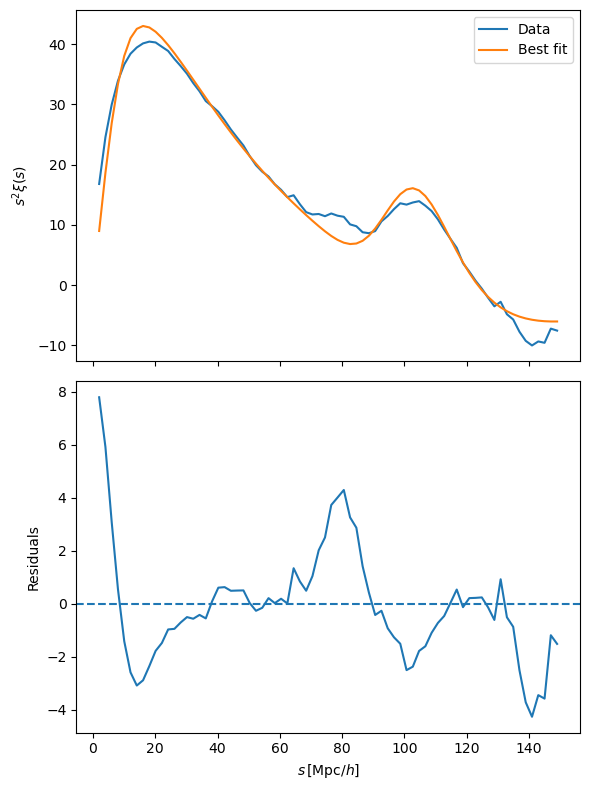

##############################Filament Galaxies##############################

=== BAO FIT RESULTS ===
alpha  = 0.9668
B      = 0.4639
Sigma  = 6.0085
A0, A1, A2 = -0.0003, -0.0385, -0.0007



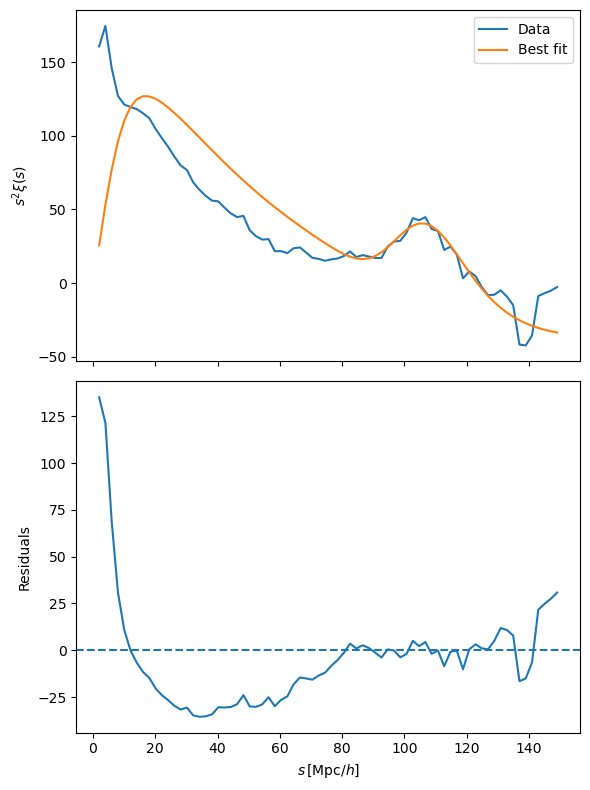

##############################Non-filament Galaxies##############################

=== BAO FIT RESULTS ===
alpha  = 0.8000
B      = 0.2149
Sigma  = 6.0112
A0, A1, A2 = 0.0005, -0.0731, -0.0014



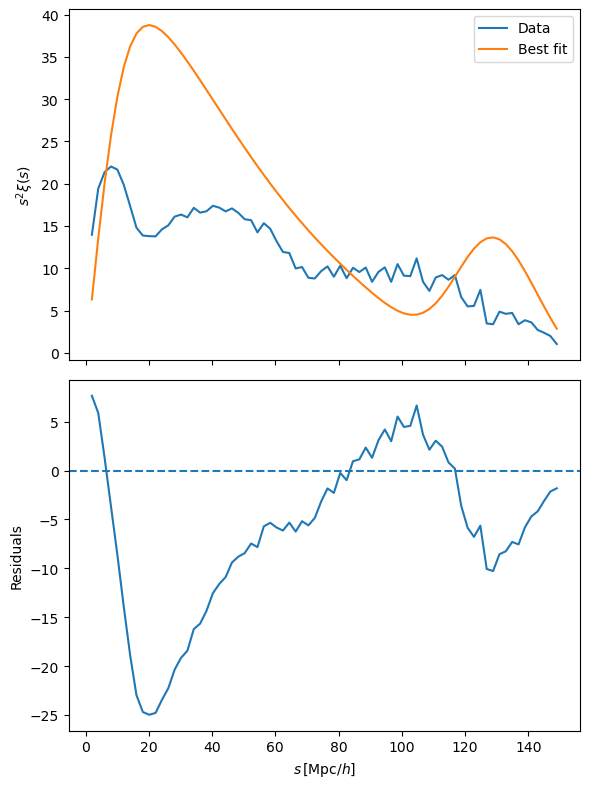

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 4.157423818188563e-06
        x: [ 8.000e-01  2.149e-01  6.011e+00  4.939e-04 -7.313e-02
            -1.376e-03]
      nit: 14
      jac: [ 5.369e-06  2.210e-06 -5.763e-07  1.727e-06 -2.142e-05
            -3.841e-07]
     nfev: 140
     njev: 20
 hess_inv: <6x6 LbfgsInvHessProduct with dtype=float64>

In [4]:
import numpy as np
import camb
from scipy.interpolate import interp1d
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ============================================================
# 0. No-wiggle P(k) (Eisenstein & Hu)
# ============================================================

def pk_nowiggle_eh(k, H0, ombh2, omch2, ns):

    h = H0 / 100.0
    Omega_b = ombh2 / h**2
    Omega_c = omch2 / h**2
    Omega_m = Omega_b + Omega_c

    f_b = Omega_b / Omega_m
    f_c = Omega_c / Omega_m

    theta = 2.725 / 2.7

    q = k * theta**2 / (Omega_m * h**2)

    alpha_c = (1 - 0.328*np.log(431*Omega_m*h**2)*Omega_b/Omega_m + 
               0.38*np.log(22.3*Omega_m*h**2)*(Omega_b/Omega_m)**2)

    beta_c = 1 / (1 + 0.2*(Omega_c*h**2)**0.5)

    L0 = np.log(2*np.e + 1.8*beta_c*q)
    C0 = 14.2 + 731/(1 + 62.5*q)

    Tc_nw = L0 / (L0 + C0*q**2)
    Tb_nw = Tc_nw

    T_nw = f_b * Tb_nw + f_c * Tc_nw

    return k**ns * T_nw**2


# ============================================================
# 1. Generate P(k)
# ============================================================

def generate_pk(z=0.0, H0=67.3, ombh2=0.022, omch2=0.119, ns=0.96,
                kmax=10.0, nk=8000):

    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2)
    pars.InitPower.set_params(ns=ns)
    pars.set_matter_power(redshifts=[z], kmax=kmax)

    results = camb.get_results(pars)

    k, _, pk = results.get_matter_power_spectrum(
        minkh=1e-4,
        maxkh=kmax,
        npoints=nk
    )

    pk = pk[0] * 15.0

    # No-wiggle
    pk_smooth = pk_nowiggle_eh(k, H0, ombh2, omch2, ns)

    k_match = (k > 1e-4) & (k < 0.05)
    norm = np.mean(pk[k_match] / pk_smooth[k_match])
    pk_smooth *= norm

    return k, pk, pk_smooth


# ============================================================
# 2. Fourier transform P(k) → xi(s)
# ============================================================

def xi_from_pk(k, pk, s_arr):

    xi = []

    # high-k stabilization
    k_cut = 5.0
    window = np.exp(-(k / k_cut)**2)

    for r in s_arr:
        sinc = np.sin(k * r) / (k * r)
        integrand = k**2 * pk * window * sinc
        xi.append(np.trapezoid(integrand, k) / (2 * np.pi**2))

    return np.array(xi)


# ============================================================
# 3. BAO model (CORRECT)
# ============================================================

def xi_model(s, params, k, pk, pk_smooth, s_temp):

    alpha, B, Sigma, A0, A1, A2 = params

    # --- k-space BAO damping ---
    damping = np.exp(-k**2 * Sigma**2 / 2)
    pk_model = pk_smooth + (pk - pk_smooth) * damping

    # --- Fourier transform ---
    xi_temp = xi_from_pk(k, pk_model, s_temp)

    # --- scale shift ---
    interp = interp1d(s_temp, xi_temp, fill_value="extrapolate")
    s_scaled = alpha * s
    xi_scaled = interp(s_scaled)

    # --- broadband ---
    xi_final = B**2 * xi_scaled + A0 + A1/s + A2/s**2

    return xi_final


# ============================================================
# 4. Chi^2
# ============================================================

def chi2(params, s, xi, k, pk, pk_smooth, s_temp):
    model = xi_model(s, params, k, pk, pk_smooth, s_temp)
    return np.sum((xi - model)**2)


# ============================================================
# 5. Fit
# ============================================================

def fit_bao(s, xi, k, pk, pk_smooth, s_temp, fit_range=(70,150)):

    mask = (s >= fit_range[0]) & (s <= fit_range[1])
    s_fit  = s[mask]
    xi_fit = xi[mask]

    p0 = [1.0, 1.0, 6.0, 0.0, 0.0, 0.0]

    bounds = [
        (0.8, 1.2),   # alpha
        (0, None),    # B
        (0, 20),      # Sigma
        (None, None),
        (None, None),
        (None, None)
    ]

    result = minimize(
        chi2,
        p0,
        args=(s_fit, xi_fit, k, pk, pk_smooth, s_temp),
        method='L-BFGS-B',
        bounds=bounds
    )

    return result


# ============================================================
# 6. Plot
# ============================================================

def plot_fit(s, xi, result, k, pk, pk_smooth, s_temp):

    xi_best = xi_model(s, result.x, k, pk, pk_smooth, s_temp)
    residuals = xi - xi_best

    fig, ax = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

    ax[0].plot(s, xi * s**2, label='Data')
    ax[0].plot(s, xi_best * s**2, label='Best fit')
    ax[0].legend()
    ax[0].set_ylabel(r'$s^2 \xi(s)$')

    ax[1].plot(s, residuals * s**2)
    ax[1].axhline(0, linestyle='--')
    ax[1].set_xlabel(r'$s \, [\mathrm{Mpc}/h]$')
    ax[1].set_ylabel("Residuals")

    plt.tight_layout()
    plt.show()


# ============================================================
# 7. Load monopole
# ============================================================

def load_monopole(filename):
    data = np.load(filename)
    return data['s'], data['xi0']


# ============================================================
# 8. High-level runner
# ============================================================

def run_bao_fit(monopole_file, fit_range=(80,140)):

    # Data
    s, xi = load_monopole(monopole_file)

    # Theory
    k, pk, pk_smooth = generate_pk()
    s_temp = np.linspace(1, 200, 5000)

    # Fit
    result = fit_bao(s, xi, k, pk, pk_smooth, s_temp, fit_range)

    print("\n=== BAO FIT RESULTS ===")
    print(f"alpha  = {result.x[0]:.4f}")
    print(f"B      = {result.x[1]:.4f}")
    print(f"Sigma  = {result.x[2]:.4f}")
    print(f"A0, A1, A2 = {result.x[3]:.4f}, {result.x[4]:.4f}, {result.x[5]:.4f}")
    print("=======================\n")

    # Plot
    plot_fit(s, xi, result, k, pk, pk_smooth, s_temp)

    return result


# ============================================================
# RUN
# ============================================================
print(
    '##############################'+'\n'
    'Full Sample'+'\n'
    '##############################'
    )
run_bao_fit(
    monopole_file='../data/monopoles/box/mag=-21.2_sep=1.0-150.0_binsep=2.0_full.npz'
)
print(
    '##############################'+'\n'
    'Filament Galaxies'+'\n'
    '##############################'
    )
run_bao_fit(
    monopole_file='../data/monopoles/box/mag=-21.2_sep=1.0-150.0_binsep=2.0_0.0-d_mathrmfilleq3.0.npz'
)
print(
    '##############################'+'\n'
    'Non-filament Galaxies'+'\n'
    '##############################'
    )
run_bao_fit(
    monopole_file='../data/monopoles/box/mag=-21.2_sep=1.0-150.0_binsep=2.0_8.0-d_mathrmfilleq100.0.npz'
)

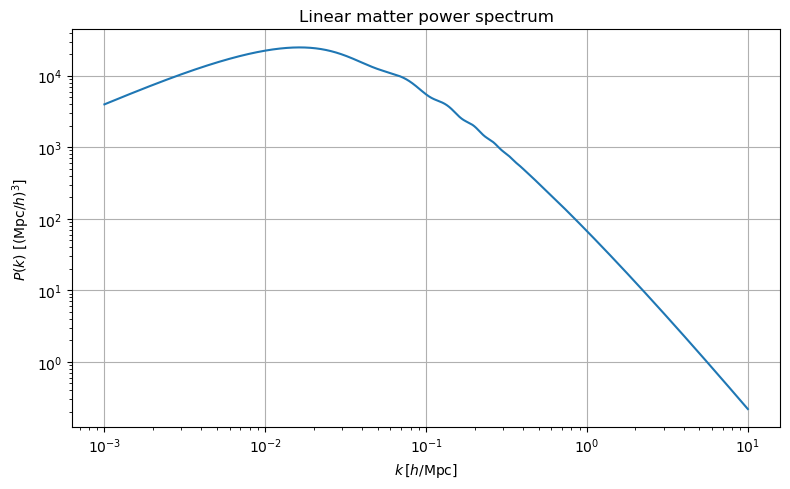

In [67]:
import numpy as np
import camb
import matplotlib.pyplot as plt

# Cosmology
H0 = 67.7
omega_b = 0.022
omega_cdm = 0.12
ns = 0.96
As = 2.1e-9

pars = camb.CAMBparams()
pars.set_cosmology(H0=H0, ombh2=omega_b, omch2=omega_cdm)
pars.InitPower.set_params(As=As, ns=ns)

# Define k range in h/Mpc (CAMB default)
k_min_hMpc = 1e-3
k_max_hMpc = 10.0
pars.set_matter_power(redshifts=[0], kmax=k_max_hMpc)

results = camb.get_results(pars)
kh, z, pk = results.get_matter_power_spectrum(minkh=k_min_hMpc, maxkh=k_max_hMpc, npoints=10000)
Plin = pk[0]          # units: (Mpc/h)^3

plt.figure(figsize=(8,5))
plt.loglog(kh, Plin)
plt.xlabel(r'$k \, [h/\mathrm{Mpc}]$')
plt.ylabel(r'$P(k) \ [(\mathrm{Mpc}/h)^3]$')
plt.title("Linear matter power spectrum")
plt.grid()
plt.tight_layout()
plt.show()

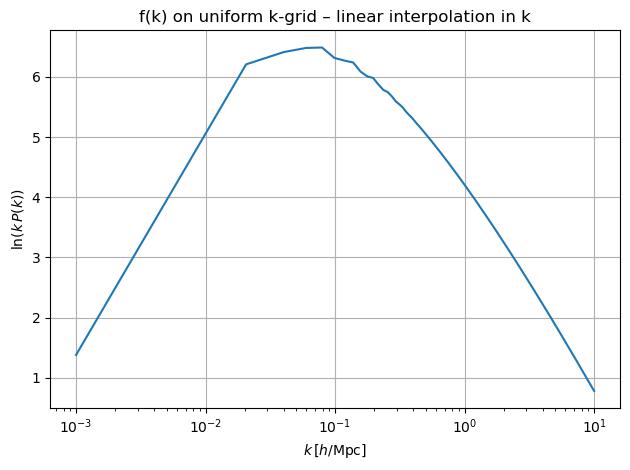

In [68]:
from scipy.interpolate import interp1d

# Uniform grid in k (h/Mpc) – 2^9 = 512 points
n = 9
N = 2**n
k = np.linspace(k_min_hMpc, k_max_hMpc, N)

# Linear interpolation of ln(k*P) in k-space (not log k)
interp_lnkP = interp1d(kh, np.log(kh * Plin), kind='linear', fill_value='extrapolate')

# Evaluate at the uniform k grid
lnkP = interp_lnkP(k)
f = lnkP          # f(k) = ln(k * P(k))

plt.figure()
plt.plot(k, f)
plt.xlabel(r'$k \, [h/\mathrm{Mpc}]$')
plt.ylabel(r'$\ln(k\,P(k))$')
plt.xscale('log')
plt.title('f(k) on uniform k-grid – linear interpolation in k')
plt.grid()
plt.tight_layout()
plt.show()

In [69]:
# Do fast sine transform of lnkP

from scipy.fftpack import dst

fst_lnkP = dst(lnkP, type=2)

print("First 10 coefficients of the fast sine transform of ln(kP):")
print(fst_lnkP[:10])

First 10 coefficients of the fast sine transform of ln(kP):
[1344.72616978  598.60017334  618.71687052  366.84271542  410.17430394
  268.00912403  308.98187164  212.0951159   248.52578036  175.78081162]


In [ ]:
import numpy as np
from scipy.interpolate import CubicSpline

# Assuming k (uniform, h/Mpc) and f (ln(kP)) are already defined from previous cells
N = len(k)
even_mask = (np.arange(N) % 2 == 0)
odd_mask  = ~even_mask

spline_even = CubicSpline(k[even_mask], f[even_mask], bc_type='natural')
spline_odd  = CubicSpline(k[odd_mask],  f[odd_mask],  bc_type='natural')

# Fine k grid for smooth evaluation
k_fine = np.linspace(k.min(), k.max(), 2000)

# Second derivative: use spline.derivative(2) to get a PPoly object
d2_even = spline_even.derivative(2)   # returns a PPoly
d2_odd  = spline_odd.derivative(2)

# Evaluate on the fine grid
d2_even_vals = d2_even(k_fine)
d2_odd_vals  = d2_odd(k_fine)

In [ ]:
import numpy as np
from scipy.interpolate import CubicSpline

def find_k_large_curvature(k_data, f_data, threshold_percentile=95, n_fine=5000):
    """
    Returns k values where |d²f/dk²| is large (above given percentile threshold).
    
    Parameters:
    - k_data: 1D array, original wavenumbers (h/Mpc)
    - f_data: 1D array, f(k) = ln(k * P(k))
    - threshold_percentile: percentile of absolute second derivative to define "large" (e.g., 95)
    - n_fine: number of points for fine evaluation grid
    
    Returns:
    - k_large: sorted array of k where curvature is large
    - spline: the CubicSpline object (for further inspection)
    - d2_fine: second derivative evaluated on fine grid
    - k_fine: fine grid
    """
    # Create cubic spline
    spline = CubicSpline(k_data, f_data, bc_type='natural')
    
    # Second derivative as a function
    d2_spline = spline.derivative(2)
    
    # Fine grid covering the original range
    k_fine = np.linspace(k_data.min(), k_data.max(), n_fine)
    d2_fine = d2_spline(k_fine)
    abs_d2 = np.abs(d2_fine)
    
    # Define threshold
    threshold = np.percentile(abs_d2, threshold_percentile)
    
    # Find indices where curvature exceeds threshold
    large_mask = abs_d2 > threshold
    k_large = k_fine[large_mask]
    
    # Print summary
    print(f"Threshold (|d²f/dk²|) = {threshold:.3g}")
    print(f"Number of k points with large curvature: {len(k_large)}")
    if len(k_large) > 0:
        print(f"Range of large k: {k_large.min():.4f} to {k_large.max():.4f} h/Mpc")
    
    return k_large, spline, d2_fine, k_fine

# Assuming you already have:
# k_full (uniform, h/Mpc), f_full (ln(kP))
# even_mask, odd_mask as before

# Even spline
k_large_even, spl_even, d2_even_fine, k_fine = find_k_large_curvature(
    k_full[even_mask], f_full[even_mask], threshold_percentile=95
)

# Odd spline
k_large_odd, spl_odd, d2_odd_fine, _ = find_k_large_curvature(
    k_full[odd_mask], f_full[odd_mask], threshold_percentile=95
)

# The actual k values (in h/Mpc) where curvature is large:
print("Even spline – large curvature at k =", k_large_even[:10], "...")   # first 10
print("Odd spline  – large curvature at k =", k_large_odd[:10], "...")

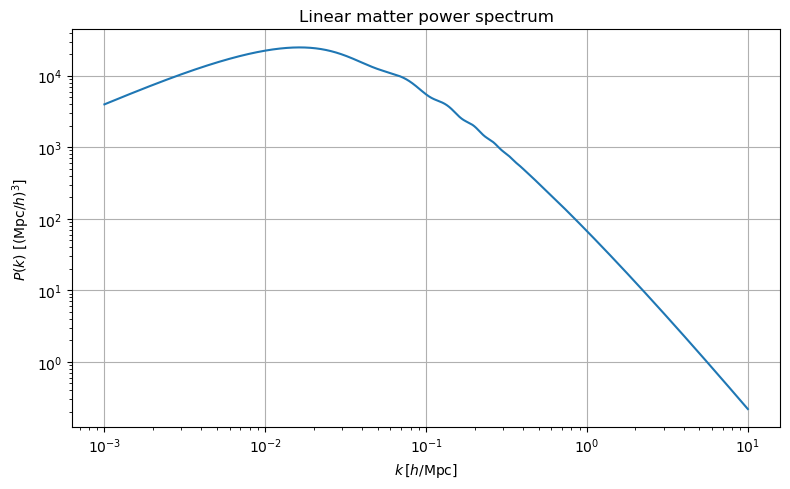

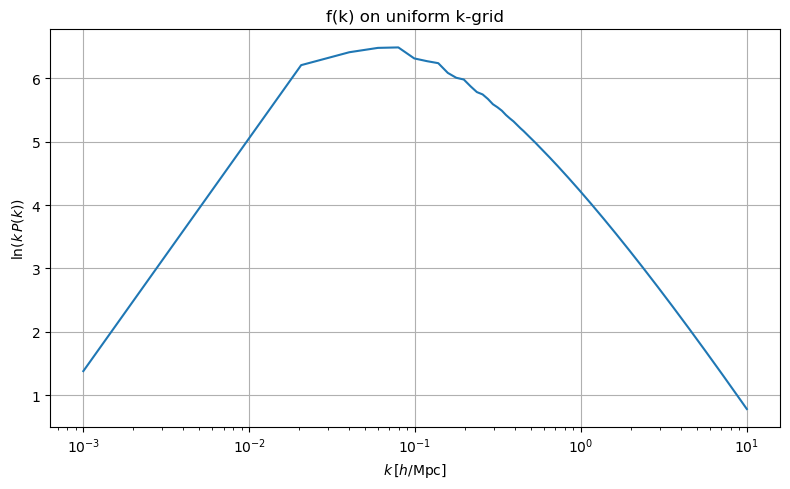


Even spline:
  Threshold = 255, 25 points found.
Odd spline:
  Threshold = 188, 25 points found.


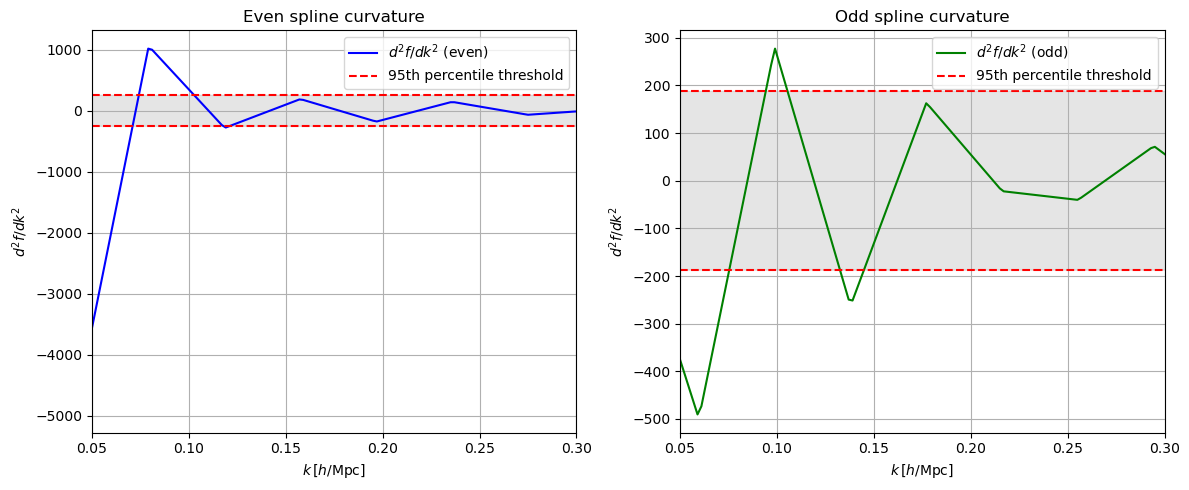


=== k values (h/Mpc) with large curvature (|d2f/dk2| > 95th percentile) ===
Even spline – first 20 points:
[0.05101, 0.05301, 0.05501, 0.05701, 0.05901, 0.06101, 0.06301, 0.06501,
 0.06701, 0.06901, 0.07501, 0.07701, 0.07901, 0.08101, 0.08301, 0.08501,
 0.08701, 0.08901, 0.09101, 0.09301]

Odd spline – first 20 points:
[0.05101, 0.05301, 0.05501, 0.05701, 0.05901, 0.06101, 0.06301, 0.06501,
 0.06701, 0.06901, 0.07101, 0.07301, 0.07501, 0.09501, 0.09701, 0.09901,
 0.10101, 0.10301, 0.10501, 0.13301]

=== k where both splines have large curvature (within BAO range) ===
Number of such points: 2
k range: 0.05970 to 0.09884 h/Mpc
First 10 bad k values:
[0.0597 , 0.09884]


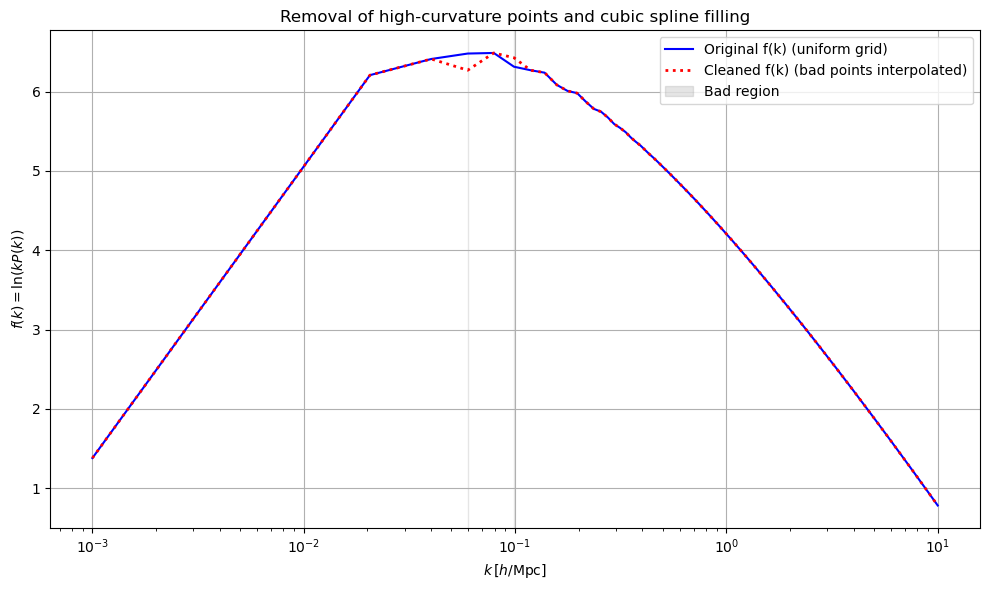

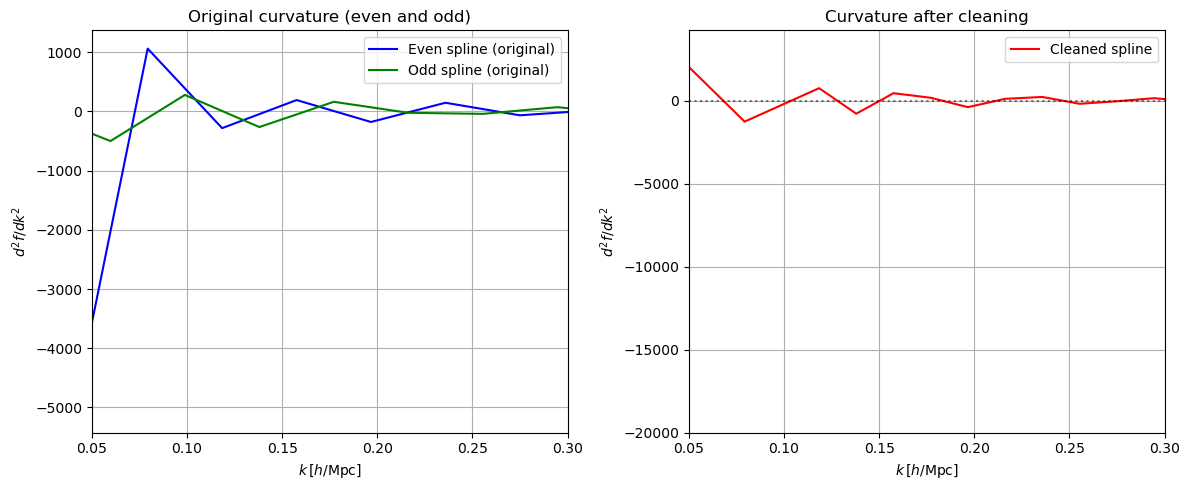


=== Interpolated values at bad k points ===
k (h/Mpc)    Original f(k)    Cleaned f(k)
 0.05970        6.479703        6.269418
 0.09884        6.313513        6.426645


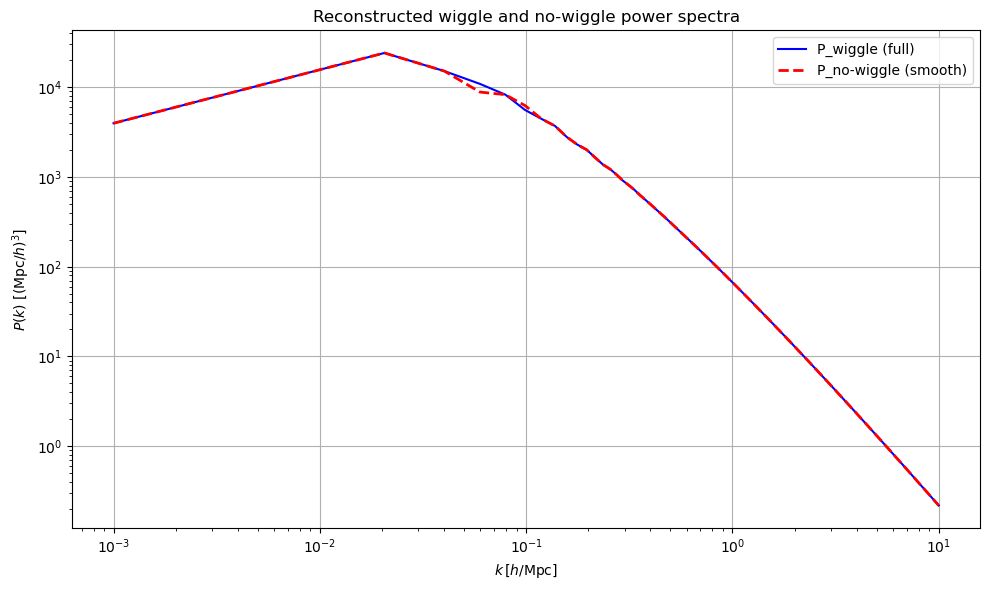

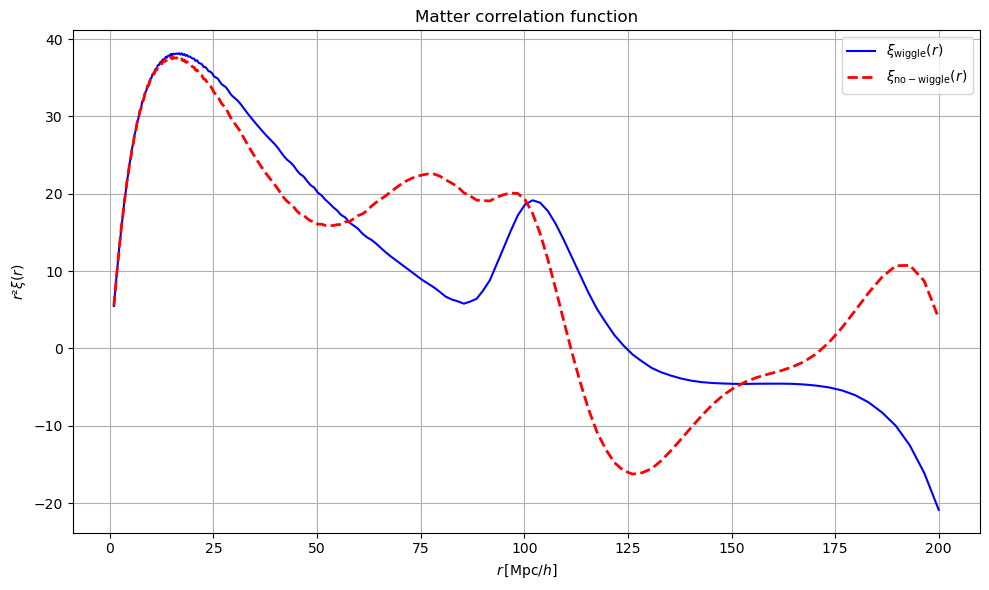

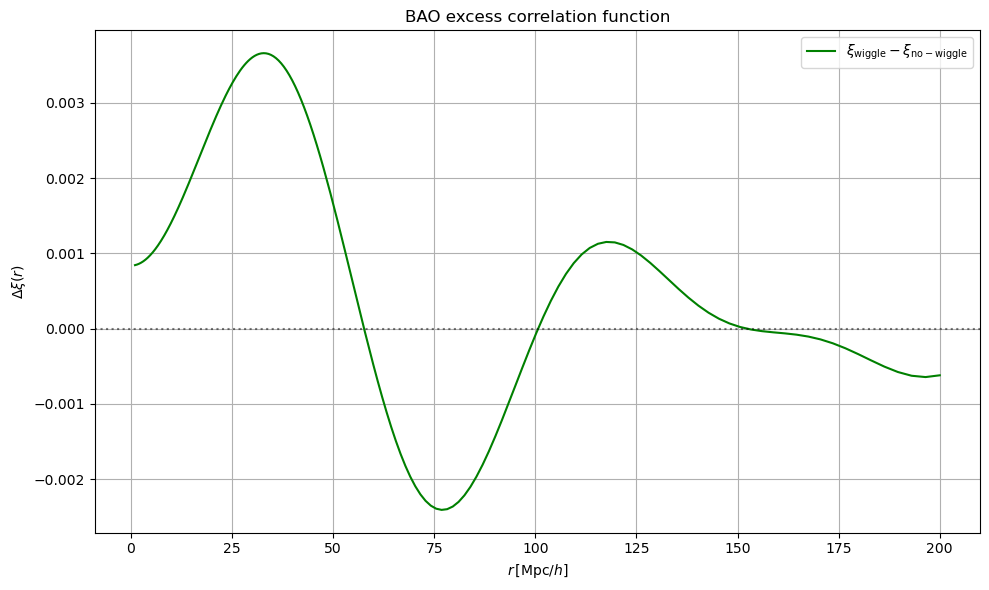

Done! Correlation functions computed.


In [ ]:
import numpy as np
import camb
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline

# ============================================================================
# 1. Compute linear matter power spectrum with CAMB
# ============================================================================

# Cosmological parameters
H0 = 67.7                 # km/s/Mpc
omega_b = 0.022           # baryon density * h^2
omega_cdm = 0.12          # cold dark matter density * h^2
ns = 0.96                 # scalar spectral index
As = 2.1e-9               # primordial amplitude

# Set up CAMB
pars = camb.CAMBparams()
pars.set_cosmology(H0=H0, ombh2=omega_b, omch2=omega_cdm)
pars.InitPower.set_params(As=As, ns=ns)

# k range in h/Mpc (native CAMB units)
k_min_hMpc = 1e-3
k_max_hMpc = 10.0
pars.set_matter_power(redshifts=[0], kmax=k_max_hMpc)

# k range for BAO
k_min_BAO = 0.05
k_max_BAO = 0.3

# percentile for large curvature
percentile_d2 = 80

# Compute power spectrum
results = camb.get_results(pars)
kh, z, pk = results.get_matter_power_spectrum(minkh=k_min_hMpc, maxkh=k_max_hMpc, npoints=10000)
Plin = pk[0]                       # units: (Mpc/h)^3

# Plot linear power spectrum
plt.figure(figsize=(8,5))
plt.loglog(kh, Plin)
plt.xlabel(r'$k \, [h/\mathrm{Mpc}]$')
plt.ylabel(r'$P(k) \ [(\mathrm{Mpc}/h)^3]$')
plt.title("Linear matter power spectrum")
plt.grid()
plt.tight_layout()
plt.show()

# ============================================================================
# 2. Uniform k grid and interpolation of f(k) = ln(k P(k))
# ============================================================================

n = 9
N = 2**n                                     # 512 points
k_uniform = np.linspace(k_min_hMpc, k_max_hMpc, N)

# Linear interpolation of ln(k*P) in linear k space
interp_lnkP = interp1d(kh, np.log(kh * Plin), kind='linear',
                       fill_value='extrapolate')
lnkP_uniform = interp_lnkP(k_uniform)
f = lnkP_uniform                             # f(k) = ln(k * P(k))

# Plot f(k) on the uniform grid
plt.figure(figsize=(8,5))
plt.plot(k_uniform, f)
plt.xlabel(r'$k \, [h/\mathrm{Mpc}]$')
plt.ylabel(r'$\ln(k\,P(k))$')
plt.xscale('log')
plt.title('f(k) on uniform k-grid')
plt.grid()
plt.tight_layout()
plt.show()

# ============================================================================
# 3. Split data into even and odd indices
# ============================================================================

even_mask = (np.arange(N) % 2 == 0)
odd_mask  = ~even_mask

k_even = k_uniform[even_mask]
f_even = f[even_mask]

k_odd  = k_uniform[odd_mask]
f_odd  = f[odd_mask]

# ============================================================================
# 4. Cubic splines for even and odd subsets
# ============================================================================

# 'natural' boundary conditions (zero second derivative at ends)
spline_even = CubicSpline(k_even, f_even, bc_type='natural')
spline_odd  = CubicSpline(k_odd,  f_odd,  bc_type='natural')

# ============================================================================
# 5. Evaluate second derivatives on a fine grid
# ============================================================================

k_fine = np.linspace(k_min_hMpc, k_max_hMpc, 5000)

d2_even = spline_even.derivative(2)          # callable second derivative
d2_odd  = spline_odd.derivative(2)

d2_even_fine = d2_even(k_fine)
d2_odd_fine  = d2_odd(k_fine)

# ============================================================================
# 6. Identify k where second derivative is "large" 
# ============================================================================

def find_large_curvature_k(k_fine, d2_fine, percentile):
    """
    Returns the k values (from k_fine) where |d2f/dk2| exceeds a given percentile.
    """
    abs_d2 = np.abs(d2_fine)
    threshold = np.percentile(abs_d2, percentile)
    large_mask = abs_d2 > threshold
    k_large = k_fine[large_mask]
    print(f"  Threshold = {threshold:.3g}, {len(k_large)} points found.")
    return k_large, threshold

# Only look for large derivatives in the bao region
bao_mask = (k_fine >= k_min_BAO) & (k_fine <= k_max_BAO)

print("\nEven spline:")
k_large_even, thresh_even = find_large_curvature_k(k_fine[bao_mask], d2_even_fine[bao_mask], percentile_d2)
print("Odd spline:")
k_large_odd,  thresh_odd  = find_large_curvature_k(k_fine[bao_mask], d2_odd_fine[bao_mask],  percentile_d2)

# ============================================================================
# 7. Plot the second derivatives and highlight large‑curvature regions
# ============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# Even spline
ax1.plot(k_fine, d2_even_fine, 'b-', label=r'$d^2f/dk^2$ (even)')
ax1.axhline( thresh_even, color='r', linestyle='--', label='95th percentile threshold')
ax1.axhline(-thresh_even, color='r', linestyle='--')
ax1.fill_between(k_fine, -thresh_even, thresh_even, color='gray', alpha=0.2)
ax1.set_xlabel(r'$k \, [h/\mathrm{Mpc}]$')
ax1.set_ylabel(r'$d^2f/dk^2$')
ax1.set_title('Even spline curvature')
ax1.legend()
ax1.set_xlim(k_min_BAO, k_max_BAO)
ax1.grid(True)

# Odd spline
ax2.plot(k_fine, d2_odd_fine, 'g-', label=r'$d^2f/dk^2$ (odd)')
ax2.axhline( thresh_odd, color='r', linestyle='--', label='95th percentile threshold')
ax2.axhline(-thresh_odd, color='r', linestyle='--')
ax2.fill_between(k_fine, -thresh_odd, thresh_odd, color='gray', alpha=0.2)
ax2.set_xlabel(r'$k \, [h/\mathrm{Mpc}]$')
ax2.set_ylabel(r'$d^2f/dk^2$')
ax2.set_title('Odd spline curvature')
ax2.set_xlim(k_min_BAO, k_max_BAO)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# ============================================================================
# 8. Print the actual k values where curvature is large
# ============================================================================

print("\n=== k values (h/Mpc) with large curvature (|d2f/dk2| > 95th percentile) ===")
print("Even spline – first 20 points:")
print(np.array2string(k_large_even[:20], precision=5, separator=', '))
print("\nOdd spline – first 20 points:")
print(np.array2string(k_large_odd[:20], precision=5, separator=', '))

# Optional: save to file
# np.savetxt('k_large_even.txt', k_large_even)
# np.savetxt('k_large_odd.txt',  k_large_odd)
# ============================================================================
# 9. Find k where BOTH even and odd splines have large curvature,
#    but only within the BAO k-range
# ============================================================================

# Evaluate second derivatives on the UNIFORM k grid
d2_even_uniform = d2_even(k_uniform)
d2_odd_uniform  = d2_odd(k_uniform)

# Use thresholds computed from BAO region only
thresh_even_abs = thresh_even
thresh_odd_abs  = thresh_odd

# Create mask for BAO region on the uniform grid
bao_mask_uniform = (k_uniform >= k_min_BAO) & (k_uniform <= k_max_BAO)

# Mask where BOTH derivatives exceed thresholds AND point is inside BAO range
both_large = (np.abs(d2_even_uniform) > thresh_even_abs) & \
             (np.abs(d2_odd_uniform) > thresh_odd_abs) & \
             bao_mask_uniform

k_bad = k_uniform[both_large]

print("\n=== k where both splines have large curvature (within BAO range) ===")
print(f"Number of such points: {len(k_bad)}")
if len(k_bad) > 0:
    print(f"k range: {k_bad.min():.5f} to {k_bad.max():.5f} h/Mpc")
    print("First 10 bad k values:")
    print(np.array2string(k_bad[:10], precision=5, separator=', '))

# ============================================================================
# 10. Remove bad points (only inside BAO) and fill gaps with cubic spline
# ============================================================================

# Good points: all points that are NOT bad (including all outside BAO)
good_mask = ~both_large
k_good = k_uniform[good_mask]
f_good = f[good_mask]

# Fit a cubic spline to the good points (works across full k range)
spline_clean = CubicSpline(k_good, f_good, bc_type='natural')

# Evaluate cleaned spline only where we want to replace values:
# - Inside BAO region, use the spline to fill gaps
# - Outside BAO region, keep the original f(k)
f_clean = f.copy()                      # start with original
f_clean[bao_mask_uniform] = spline_clean(k_uniform[bao_mask_uniform])
# ============================================================================
# 11. Visualisation: original vs cleaned f(k)
# ============================================================================

plt.figure(figsize=(10,6))

# Plot original f(k)
plt.plot(k_uniform, f, 'b-', label='Original f(k) (uniform grid)', linewidth=1.5)

# Plot cleaned f(k)
plt.plot(k_uniform, f_clean, 'r:', label='Cleaned f(k) (bad points interpolated)', linewidth=2)

# Highlight the bad k regions
if len(k_bad) > 0:
    # Find contiguous blocks of bad points
    bad_diff = np.diff(both_large.astype(int))
    starts = np.where(bad_diff == 1)[0] + 1
    ends   = np.where(bad_diff == -1)[0] + 1
    if both_large[0]:
        starts = np.insert(starts, 0, 0)
    if both_large[-1]:
        ends = np.append(ends, len(k_uniform))
    for s, e in zip(starts, ends):
        plt.axvspan(k_uniform[s], k_uniform[e-1], alpha=0.2, color='gray', label='Bad region' if s==starts[0] else '')

plt.xlabel(r'$k \, [h/\mathrm{Mpc}]$')
plt.ylabel(r'$f(k) = \ln(k P(k))$')
plt.title('Removal of high‑curvature points and cubic spline filling')
plt.legend()
plt.grid(True)
plt.xscale('log')   # because your previous plot used log scale
plt.tight_layout()
plt.show()

# ============================================================================
# 12. (Optional) Compare second derivatives before and after cleaning
# ============================================================================

# Second derivative of the cleaned spline
d2_clean = spline_clean.derivative(2)
d2_clean_uniform = d2_clean(k_uniform)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# Even spline original curvature (as before)
ax1.plot(k_uniform, d2_even_uniform, 'b-', label='Even spline (original)')
ax1.plot(k_uniform, d2_odd_uniform,  'g-', label='Odd spline (original)')
ax1.set_xlabel(r'$k \, [h/\mathrm{Mpc}]$')
ax1.set_ylabel(r'$d^2f/dk^2$')
ax1.set_title('Original curvature (even and odd)')
ax1.set_xlim(k_min_BAO, k_max_BAO)
ax1.legend()
ax1.grid(True)

# Cleaned spline curvature
ax2.plot(k_uniform, d2_clean_uniform, 'r-', label='Cleaned spline')
ax2.axhline(0, color='k', linestyle=':', alpha=0.5)
ax2.set_xlabel(r'$k \, [h/\mathrm{Mpc}]$')
ax2.set_ylabel(r'$d^2f/dk^2$')
ax2.set_title('Curvature after cleaning')
ax2.set_xlim(k_min_BAO, k_max_BAO)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# ============================================================================
# 13. (Optional) Print the new interpolated values at the removed k's
# ============================================================================
if len(k_bad) > 0:
    print("\n=== Interpolated values at bad k points ===")
    print("k (h/Mpc)    Original f(k)    Cleaned f(k)")
    for i in np.where(both_large)[0][:10]:   # first 10 bad points
        print(f"{k_uniform[i]:8.5f}    {f[i]:12.6f}    {f_clean[i]:12.6f}")


# ============================================================================
# 14. Reconstruct P_wiggle(k) and P_no‑wiggle(k) from f(k) and f_clean(k)
# ============================================================================

# f(k) = ln(k * P_full(k))   (original, includes wiggles)
# f_clean(k) = ln(k * P_nowiggle(k))  (smooth component)

# Convert back to power spectra
kP_wiggle = np.exp(f)          # = k * P_wiggle(k)
kP_nowiggle = np.exp(f_clean)  # = k * P_nowiggle(k)

# Avoid division by zero (k_uniform > 0 always)
P_wiggle = kP_wiggle / k_uniform
P_nowiggle = kP_nowiggle / k_uniform

# Plot the power spectra for comparison
plt.figure(figsize=(10,6))
plt.loglog(k_uniform, P_wiggle, 'b-', label='P_wiggle (full)', linewidth=1.5)
plt.loglog(k_uniform, P_nowiggle, 'r--', label='P_no‑wiggle (smooth)', linewidth=2)
plt.xlabel(r'$k \, [h/\mathrm{Mpc}]$')
plt.ylabel(r'$P(k) \ [(\mathrm{Mpc}/h)^3]$')
plt.title('Reconstructed wiggle and no‑wiggle power spectra')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================================
# 15. Compute correlation functions ξ(r) via Hankel transform
# ============================================================================
# Formula: ξ(r) = (1/(2π² r)) ∫₀^∞ [k P(k)] sin(k r) dk

# Define r array (Mpc/h)
r_min = 1.0
r_max = 200.0
n_r = 300
r_array = np.logspace(np.log10(r_min), np.log10(r_max), n_r)

# Pre‑compute integration factor (1/(2π²))
factor = 1.0 / (2.0 * np.pi**2)

xi_wiggle = np.zeros_like(r_array)
xi_nowiggle = np.zeros_like(r_array)

for i, r in enumerate(r_array):
    # integrand = [k P(k)] * sin(k r)
    integrand_w = kP_wiggle * np.sin(k_uniform * r)
    integrand_nw = kP_nowiggle * np.sin(k_uniform * r)
    
    # Integrate over k using Simpson's rule (trapezoidal is fine)
    xi_wiggle[i] = (factor / r) * np.trapezoid(integrand_w, k_uniform)
    xi_nowiggle[i] = (factor / r) * np.trapezoid(integrand_nw, k_uniform)

# ============================================================================
# 16. Plot correlation functions
# ============================================================================

plt.figure(figsize=(10,6))
plt.plot(r_array, xi_wiggle*r_array**2, 'b-', label=r'$\xi_{\mathrm{wiggle}}(r)$', linewidth=1.5)
plt.plot(r_array, xi_nowiggle*r_array**2, 'r--', label=r'$\xi_{\mathrm{no-wiggle}}(r)$', linewidth=2)
plt.xlabel(r'$r \, [\mathrm{Mpc}/h]$')
plt.ylabel(r'$r²\xi(r)$')
plt.title('Matter correlation function')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================================
# 17. (Optional) Compute the wiggle‑only component for the BAO signature
# ============================================================================
xi_BAO = xi_wiggle - xi_nowiggle

plt.figure(figsize=(10,6))
plt.plot(r_array, xi_BAO, 'g-', label=r'$\xi_{\mathrm{wiggle}} - \xi_{\mathrm{no-wiggle}}$')
plt.axhline(0, color='k', linestyle=':', alpha=0.5)
plt.xlabel(r'$r \, [\mathrm{Mpc}/h]$')
plt.ylabel(r'$\Delta \xi(r)$')
plt.title('BAO excess correlation function')
plt.legend()
plt.grid(True)
plt.xscale('linear')
plt.tight_layout()
plt.show()

print("Done! Correlation functions computed.")

Equality scale keq = 0.0104 h/Mpc


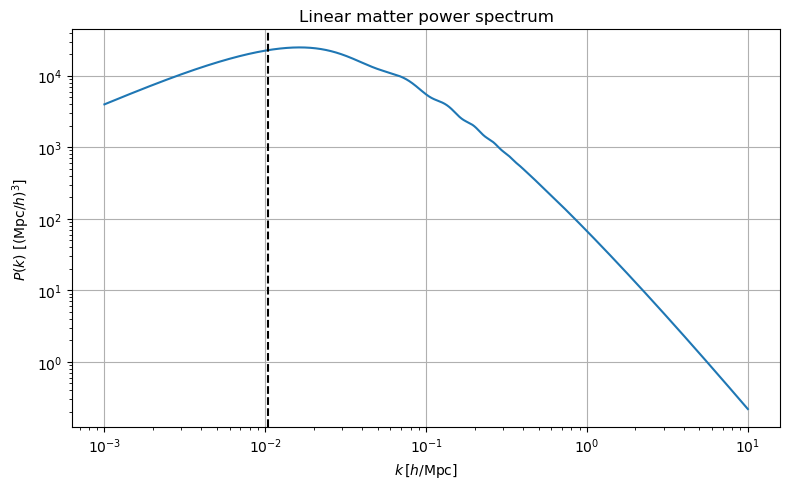

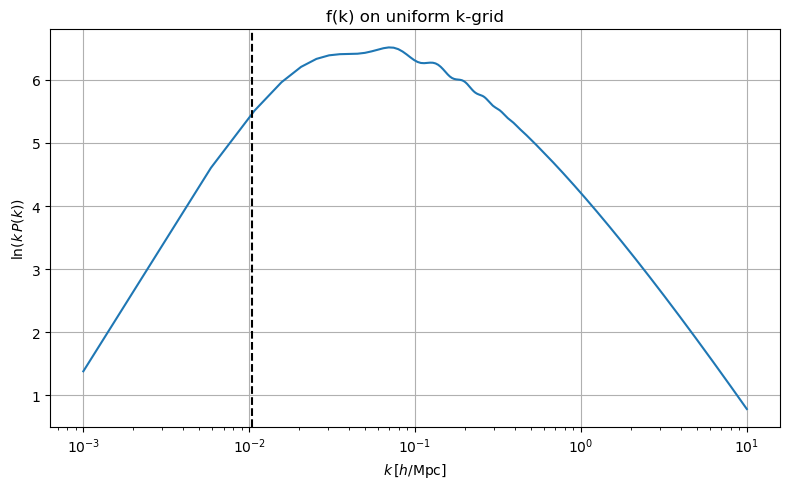


Thresholds (|d²f/dk²|, 70th percentile) in BAO range:
  Even spline: 32.1
  Odd spline:  35.7

Number of k points with both curvatures large: 58
k range: 0.04008 to 0.36735 h/Mpc
First 10 bad k values:
[0.04008, 0.04496, 0.04985, 0.05473, 0.05962, 0.0645 , 0.06939, 0.07427,
 0.07916, 0.08404]


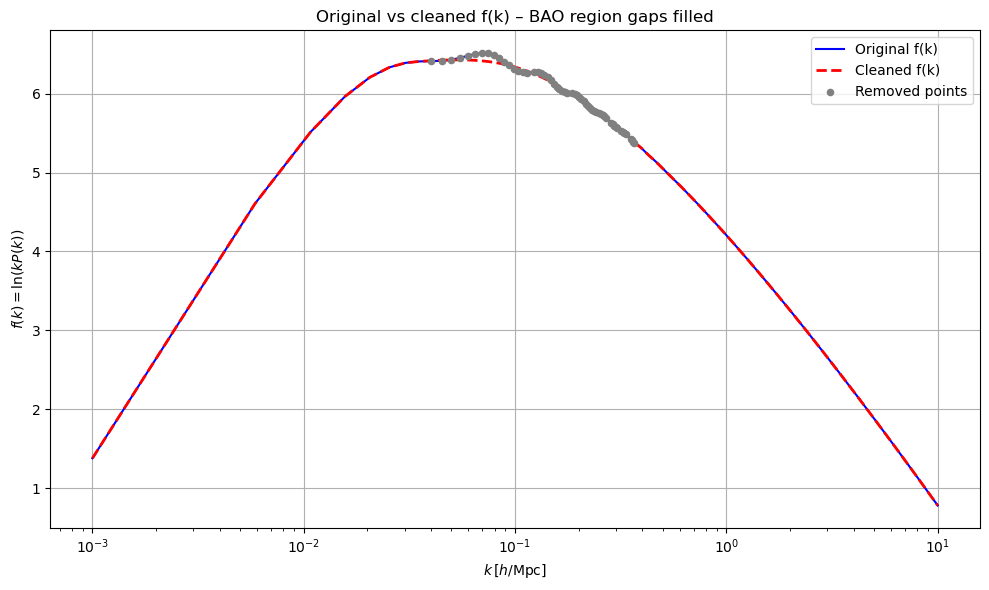

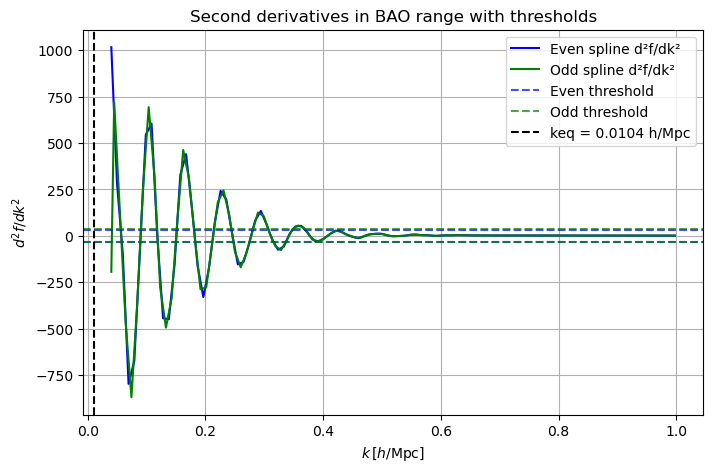

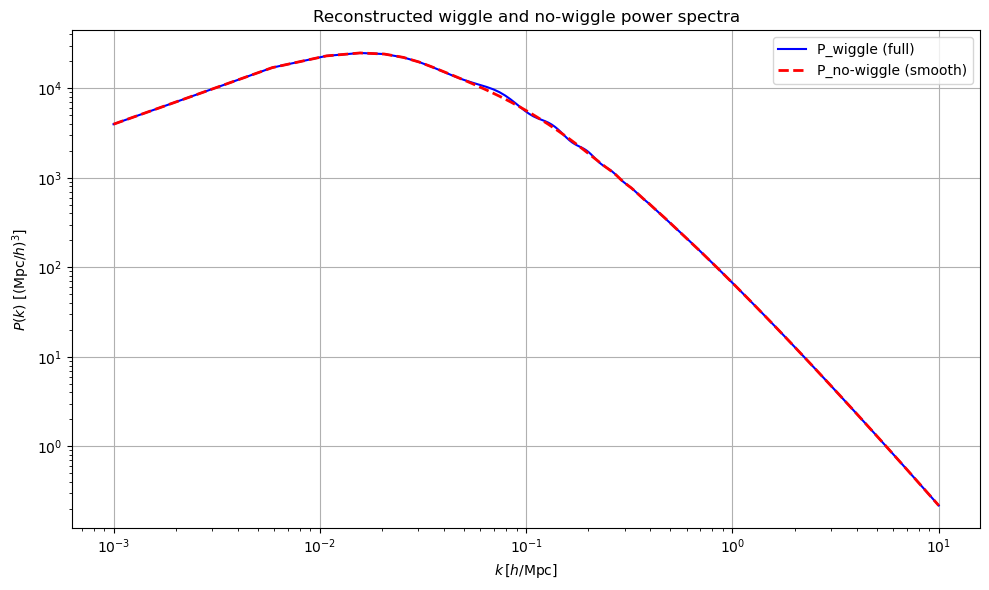

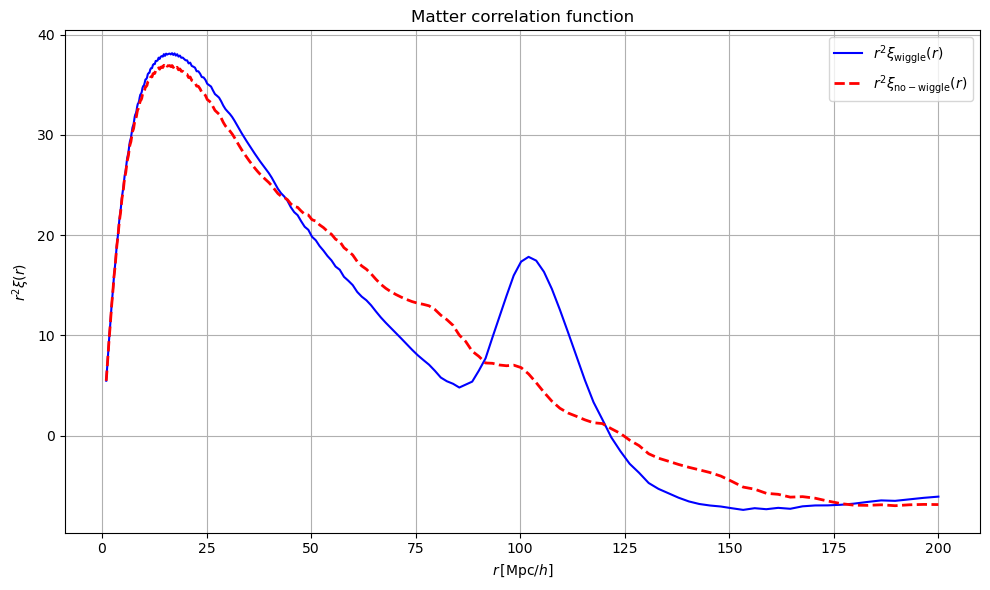

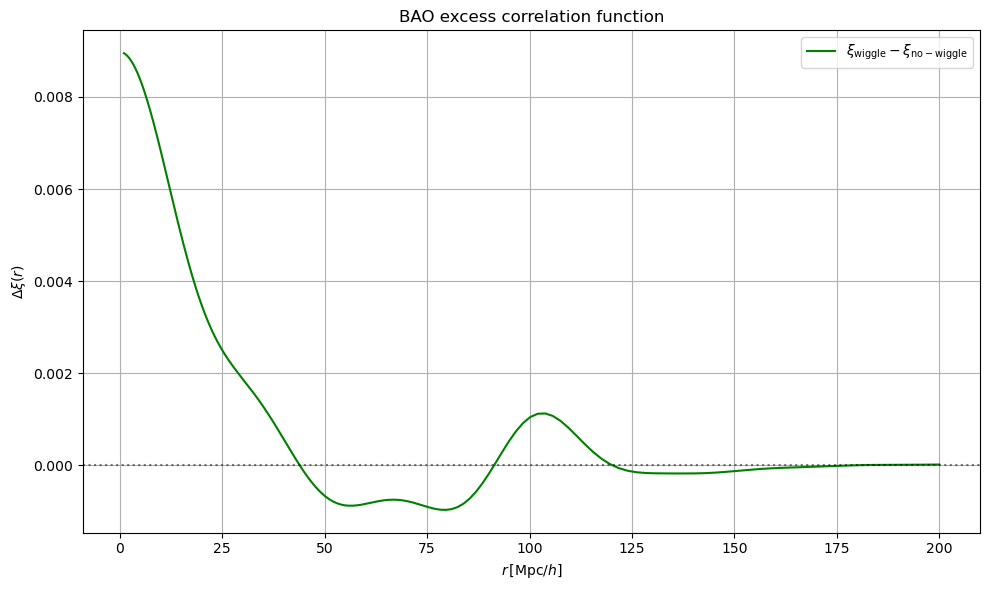

Done! Correlation functions computed.
